# EM-DAT Disaster Events

The Emergency Events Database from CRED at UCLouvain, one row per recorded disaster since 1900. It
is where every death, affected person and damage figure in this project comes from, and it is the
frame the country-year panel counts events onto.

## Provenance

These are the fields of the `EMDAT` declaration in `climate_risk/data_functions/emdat_processing.py`.
It is a `ManualSource`, so it carries a homepage rather than a URL: EM-DAT requires a registered
account and forbids redistribution, so nothing here downloads it.

In [1]:
import dataclasses

from IPython.display import Markdown

from climate_risk.data_functions.emdat_processing import EMDAT

declared = {"publisher": "CRED, UCLouvain"} | dataclasses.asdict(EMDAT)
rows = [f"| {field} | {value} |" for field, value in declared.items()]

Markdown("\n".join(["| Field | Value |", "|---|---|", *rows]))

| Field | Value |
|---|---|
| publisher | CRED, UCLouvain |
| filename | emdat.xlsx |
| homepage | https://public.emdat.be/ |
| license | Free for non-commercial use with attribution. Redistribution of the database is not permitted; users must download it themselves after registering. |
| citation | EM-DAT, CRED / UCLouvain, Brussels, Belgium. Delforge, D. et al. (2025), EM-DAT: the Emergency Events Database. International Journal of Disaster Risk Reduction 124, 105509. https://doi.org/10.1016/j.ijdrr.2025.105509 |
| retrieved | 2026-08-03 |

## Loading it

`load_emdat_events` reads the workbook you placed in the cache directory and renames its columns.
Until the file is there it raises with the license and the exact path it wants, rather than
downloading anything. The cache directory is your choice, and this page uses one named `data` in the
working directory.

In [2]:
import logging

from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

from climate_risk.data_functions.emdat_processing import load_emdat_events
from climate_risk.plotting import PALETTE, configure_plot_style

configure_plot_style(add_grid=True)

# The package installs an INFO handler when nothing else has, and a cache hit logs a line.
logging.getLogger("climate_risk").setLevel(logging.WARNING)

In [3]:
cache_dir = Path("data")

events = load_emdat_events(cache_dir)

## What you get

A polars frame, one row per event, keyed by `DisNo.`. Nothing is filtered out: every disaster type
EM-DAT records is here, including the technological ones.

In [4]:
events.select("DisNo.", "ISO", "Disaster Subgroup", "Start_Year", "Deaths", "Total_Damage_Adjusted").head()

DisNo.,ISO,Disaster Subgroup,Start_Year,Deaths,Total_Damage_Adjusted
str,str,str,date,i64,i64
"""1987-0326-JAM""","""JAM""","""Hydrological""",1987-01-01,9,87835
"""1987-0590-FSM""","""FSM""","""Meteorological""",1987-01-01,5,17000
"""1988-0312-PHL""","""PHL""","""Meteorological""",1988-01-01,6,31351
"""1988-0424-HND""","""HND""","""Meteorological""",1988-01-01,12,null
"""1989-0447-USA""","""USA""","""Meteorological""",1989-01-01,11,1298506


## Units

| Column | Unit |
|---|---|
| `DisNo.` | EM-DAT event identifier, `YYYY-NNNN-ISO` |
| `ISO` | ISO 3166-1 alpha-3 country code |
| `Start_Year` | a date, not a year |
| `Deaths`, `Injured`, `Homeless` | people |
| `Numb_Affected`, `Total_Affected` | people |
| `Total_Damage`, `Insured_Damage` | thousands of US dollars, at the time of the event |
| `Total_Damage_Adjusted`, `Insured_Damage_Adjusted` | thousands of US dollars, CPI-adjusted |
| `CPI` | the index those adjusted columns were divided by |
| `Magnitude` | depends on `Magnitude Scale`, which varies by disaster type |
| `disaster_class` | this project's label, not EM-DAT's |

The damage columns are published as `Total Damage ('000 US$)` and the loader renames them to
`Total_Damage`, which drops the unit from the name. They are thousands of dollars, so a figure of
`1000` is a million.

## Coverage

The record reaches back to 1900 and the money columns are mostly empty. Damage is reported for about
a fifth of events, so any total over this frame is a total over what was reported rather than what
happened.

In [5]:
pl.DataFrame(
    {
        "events": [len(events)],
        "countries": [events["ISO"].n_unique()],
        "first": [events["Start_Year"].min().year],
        "last": [events["Start_Year"].max().year],
    }
)

events,countries,first,last
i64,i64,i64,i64
27758,231,1900,2026


In [6]:
COUNTED = ("Deaths", "Total_Affected", "Total_Damage_Adjusted", "Magnitude")

pl.DataFrame(
    {
        "column": COUNTED,
        "reported": [events[name].is_not_null().sum() for name in COUNTED],
    }
).with_columns((pl.col("reported") / len(events)).alias("share"))

column,reported,share
str,i64,f64
"""Deaths""",22182,0.799121
"""Total_Affected""",18767,0.676093
"""Total_Damage_Adjusted""",6050,0.217955
"""Magnitude""",5508,0.198429


## A plot

Events recorded per year, split by the class this project assigns. The rise through the century is
mostly reporting rather than weather, and it is the reason a model reads rates within a country
instead of counts across the record. The unclassified line is everything `disaster_class` leaves
null, which is half the database. The collapse at the right edge is the current year, which is
only partly entered.

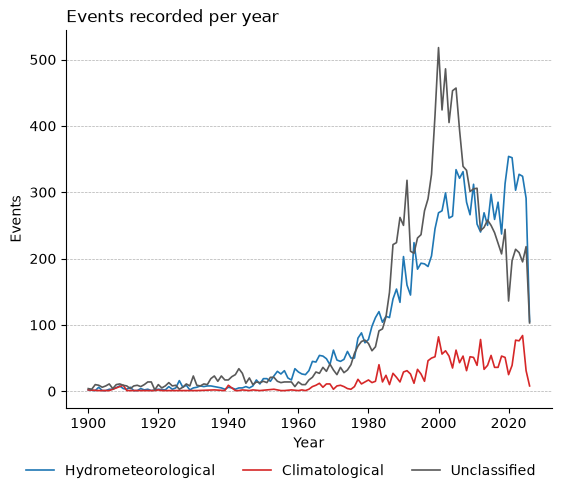

In [7]:
yearly = (
    events.with_columns(
        pl.col("Start_Year").dt.year().alias("year"),
        pl.col("disaster_class").fill_null("Unclassified"),
    )
    .group_by("year", "disaster_class")
    .len()
    .sort("year")
)

figure, axis = plt.subplots(figsize=(5.5, 4.5))
for label, color in (
    ("Hydrometeorological", PALETTE["primary"]),
    ("Climatological", PALETTE["secondary"]),
    ("Unclassified", PALETTE["divider"]),
):
    of_class = yearly.filter(pl.col("disaster_class") == label)
    axis.plot(of_class["year"], of_class["len"], color=color, lw=1.2, label=label)

axis.set_title("Events recorded per year", loc="left")
axis.set_xlabel("Year")
axis.set_ylabel("Events")

handles, labels = axis.get_legend_handles_labels()
figure.legend(handles=handles, labels=labels, loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)

plt.show()

## Gotchas

*`Start_Year` is a date.* The name says year and the dtype is `Date`, set to the first of January.
Comparing it to an integer year silently matches nothing, and `dt.year()` is what gets the number.

*Damage is in thousands of dollars and the name no longer says so.* EM-DAT publishes
`Total Damage ('000 US$)` and the loader renames it to `Total_Damage`. Reading it as dollars
understates every damage figure by a factor of a thousand.

*`disaster_class` is null for half the rows.* It labels the hydrological, meteorological and
climatological subgroups this project models and leaves everything else alone. Transport accidents
are the second largest subgroup in the database and they are disasters EM-DAT records, not errors.

*The rise in events is mostly reporting.* Coverage of the early century is thin and improves through
it. A count regressed on a trend recovers the reporting effort, not the climate.

*The database cannot be redistributed.* Non-commercial use with attribution is allowed, and passing
the workbook on is not, which is why nothing in this package fetches it for you.